# Wpływ preprocessingu na odporność modelu przy zmiennych warunkach oświetleniowych

Celem eksperymentu jest określenie, czy zastosowanie preprocessingu podczas treningu modelu ResNet50 może zwiększyć jego odporność na niekorzystne warunki oświetleniowe.

Na podstawie wcześniejszego eksperymentu przesiewowego do dalszej analizy wybrano korekcję gamma. Porównywane są trzy wartości parametru gamma:

- γ = 1.2,
- γ = 1.5,
- γ = 1.8,

oraz konfiguracja referencyjna bez dodatkowego preprocessingu.

Wszystkie konfiguracje wykorzystują tę samą architekturę `ResNet50`, strategię `WeightedRandomSampler`, ten sam podział danych oraz identyczne parametry procesu uczenia.

Eksperyment obejmuje:
1. trening przy zamrożonym backbone,
2. fine-tuning końcowego bloku modelu,
3. ocenę skuteczności na standardowym zbiorze walidacyjnym,
4. ocenę odporności na kontrolowane poziomy zaciemnienia.

Podstawowym kryterium wyboru konfiguracji jest średnia wartość `Macro F1` dla wariantów `dark_1`, `dark_2` i `dark_3` na zbiorze walidacyjnym.

Zbiór `test_final` zostanie wykorzystany wyłącznie do końcowej oceny wybranej konfiguracji.

In [ ]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.preprocessing import (
    build_preprocessing_train_transform,
    build_preprocessing_eval_transform,
)

from src.data.sampling import (
    build_weighted_sampler,
)

from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
)

from src.models.resnet50 import (
    create_resnet50,
    freeze_resnet50_backbone,
    unfreeze_resnet50_last_block,
)

from src.training.trainer import (
    fit,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

HISTORIES_DIR = (
    RESULTS_DIR
    / "histories"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "preprocessing_analysis"
)

FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)


for directory in [
    METRICS_DIR,
    HISTORIES_DIR,
    CHECKPOINT_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Konfiguracja eksperymentu

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
FROZEN_EPOCHS = 10
FINE_TUNE_EPOCHS = 5
FROZEN_LR = 1e-3
FINE_TUNE_LR = 1e-5
RANDOM_SEED = 42
PRETRAINED = True

CONFIGURATIONS = [
    {
        "name": "original",
        "method": "original",
        "gamma": None,
    },

    {
        "name": "gamma_1.2",
        "method": "gamma",
        "gamma": 1.2,
    },

    {
        "name": "gamma_1.5",
        "method": "gamma",
        "gamma": 1.5,
    },

    {
        "name": "gamma_1.8",
        "method": "gamma",
        "gamma": 1.8,
    },
]


DARK_VARIANTS = [
    "dark_1",
    "dark_2",
    "dark_3",
]


BRIGHT_VARIANTS = [
    "bright_1",
    "bright_2",
    "bright_3",
]


print(
    "Konfiguracje:"
)

for configuration in CONFIGURATIONS:
    print(
        configuration
    )

Konfiguracje:
{'name': 'original', 'method': 'original', 'gamma': None}
{'name': 'gamma_1.2', 'method': 'gamma', 'gamma': 1.2}
{'name': 'gamma_1.5', 'method': 'gamma', 'gamma': 1.5}
{'name': 'gamma_1.8', 'method': 'gamma', 'gamma': 1.8}


## 2. Przygotowanie manifestów i mapowania klas

In [3]:
TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "TRAIN:",
    len(train_df)
)

print(
    "VALIDATION:",
    len(validation_df)
)

print(
    "TEST_FINAL:",
    len(test_df)
)

Liczba klas: 92
TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 3. Przygotowanie DataLoaderów

Dla każdej konfiguracji preprocessing jest stosowany zarówno do zbioru treningowego, jak i do danych walidacyjnych.

Zbiór treningowy wykorzystuje `WeightedRandomSampler`.

In [4]:
def build_training_loaders(
    method,
    gamma=None,
):

    gamma_value = (
        1.5
        if gamma is None
        else gamma
    )


    train_transform = (
        build_preprocessing_train_transform(
            method,
            image_size=IMAGE_SIZE,
            gamma=gamma_value,
        )
    )


    eval_transform = (
        build_preprocessing_eval_transform(
            method,
            image_size=IMAGE_SIZE,
            gamma=gamma_value,
        )
    )


    train_dataset = (
        TrafficSignDataset(
            TRAIN_PATH,
            class_to_idx,
            transform=train_transform,
        )
    )


    validation_dataset = (
        TrafficSignDataset(
            VALIDATION_PATH,
            class_to_idx,
            transform=eval_transform,
        )
    )


    weighted_sampler = (
        build_weighted_sampler(
            TRAIN_PATH
        )
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=weighted_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    return (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    )

## 4. Funkcja treningu jednej konfiguracji

Każda konfiguracja przechodzi dwa etapy uczenia:

1. trening głowicy klasyfikacyjnej przy zamrożonym backbone,
2. fine-tuning końcowego bloku ResNet50 oraz głowicy klasyfikacyjnej.

Najlepszy checkpoint jest wybierany na podstawie wartości `validation Macro F1`.

In [5]:
def train_configuration(
    configuration,
):

    name = configuration[
        "name"
    ]

    method = configuration[
        "method"
    ]

    gamma = configuration[
        "gamma"
    ]


    print(
        "\n"
        + "=" * 80
    )

    print(
        f"Konfiguracja: {name}"
    )

    print(
        "=" * 80
    )


    set_seed(
        RANDOM_SEED
    )


    (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    ) = build_training_loaders(
        method=method,
        gamma=gamma,
    )


    model = create_resnet50(
        num_classes=len(
            class_codes
        ),
        pretrained=PRETRAINED,
    )


    model = (
        freeze_resnet50_backbone(
            model
        )
    )


    model = model.to(
        DEVICE
    )


    criterion = (
        nn.CrossEntropyLoss()
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FROZEN_LR,
    )


    frozen_checkpoint = (
        CHECKPOINT_DIR
        / f"resnet50_{name}_frozen_best.pt"
    )


    frozen_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FROZEN_EPOCHS,
        checkpoint_path=frozen_checkpoint,
    )


    model = (
        unfreeze_resnet50_last_block(
            model
        )
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FINE_TUNE_LR,
    )


    finetuned_checkpoint = (
        CHECKPOINT_DIR
        / f"resnet50_{name}_finetuned_best.pt"
    )


    finetune_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FINE_TUNE_EPOCHS,
        checkpoint_path=finetuned_checkpoint,
    )


    model.eval()


    return {
        "configuration": configuration,
        "model": model,
        "train_dataset": train_dataset,
        "validation_dataset":
            validation_dataset,
        "train_loader":
            train_loader,
        "validation_loader":
            validation_loader,
        "frozen_history":
            frozen_history,
        "finetune_history":
            finetune_history,
    }

## 5. Trening konfiguracji

In [6]:
experiments = {}


for configuration in CONFIGURATIONS:

    result = train_configuration(
        configuration
    )

    experiments[
        configuration["name"]
    ] = result


print(
    "\nZakończono trening wszystkich konfiguracji."
)


Konfiguracja: original


Postęp treningu:   0%|          | 0/10 [00:00<?, ?it/s]

Epoka 1/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/10:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 2/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 5/5:   0%|          | 0/445 [00:00<?, ?it/s]


Zakończono trening wszystkich konfiguracji.


## 6. Porównanie skuteczności na standardowym zbiorze walidacyjnym

In [7]:
standard_validation_results = []


for name, experiment in experiments.items():

    model = experiment[
        "model"
    ]

    loader = experiment[
        "validation_loader"
    ]

    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )

    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )

    standard_validation_results.append(
        {
            "configuration":
                name,

            "accuracy":
                metrics[
                    "accuracy"
                ],

            "macro_precision":
                metrics[
                    "macro_precision"
                ],

            "macro_recall":
                metrics[
                    "macro_recall"
                ],

            "macro_f1":
                metrics[
                    "macro_f1"
                ],

            "inference_time_seconds":
                inference_time,
        }
    )


standard_validation_df = (
    pd.DataFrame(
        standard_validation_results
    )
    .sort_values(
        "macro_f1",
        ascending=False,
    )
)


display(
    standard_validation_df
)


standard_validation_df.to_csv(
    METRICS_DIR
    / "trained_gamma_standard_validation.csv",
    index=False,
    encoding="utf-8-sig",
)

,configuration,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
1,gamma_1.2,0.939092,0.932235,0.937857,0.931186,212.127543
0,original,0.937102,0.928367,0.931038,0.925461,218.748908
2,gamma_1.5,0.933917,0.929219,0.925226,0.923304,207.542392
3,gamma_1.8,0.929140,0.917471,0.910609,0.910144,208.415979


## 7. Ocena odporności na kontrolowane zaciemnienie

Każda wytrenowana konfiguracja jest oceniana na identycznych wariantach kontrolowanego zaciemnienia.

Zmienna oświetleniowa jest modyfikowana przed zastosowaniem preprocessingu, zgodnie z kolejnością przetwarzania obrazu w badanym pipeline.

In [8]:
def evaluate_on_lighting_variant(
    model,
    preprocessing_method,
    gamma,
    variant,
):

    gamma_value = (
        1.5
        if gamma is None
        else gamma
    )


    transform = (
        build_preprocessing_eval_transform(
            preprocessing_method,
            image_size=IMAGE_SIZE,
            gamma=gamma_value,
        )
    )


    dataset = (
        ControlledLightingDataset(
            VALIDATION_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=transform,
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    return {
        "accuracy":
            metrics["accuracy"],

        "macro_precision":
            metrics["macro_precision"],

        "macro_recall":
            metrics["macro_recall"],

        "macro_f1":
            metrics["macro_f1"],

        "inference_time_seconds":
            inference_time,

        "samples":
            len(dataset),
    }

In [9]:
dark_results = []


for name, experiment in experiments.items():

    configuration = (
        experiment[
            "configuration"
        ]
    )

    model = experiment[
        "model"
    ]


    for variant in DARK_VARIANTS:

        print(
            f"Konfiguracja: {name} | "
            f"Wariant: {variant}"
        )


        result = evaluate_on_lighting_variant(
            model=model,
            preprocessing_method=(
                configuration[
                    "method"
                ]
            ),
            gamma=(
                configuration[
                    "gamma"
                ]
            ),
            variant=variant,
        )


        dark_results.append(
            {
                "configuration":
                    name,

                "variant":
                    variant,

                "factor":
                    LIGHTING_FACTORS[
                        variant
                    ],

                **result,
            }
        )


dark_results_df = pd.DataFrame(
    dark_results
)


display(
    dark_results_df
)


dark_results_df.to_csv(
    METRICS_DIR
    / "trained_gamma_dark_validation.csv",
    index=False,
    encoding="utf-8-sig",
)

Konfiguracja: original | Wariant: dark_1
Konfiguracja: original | Wariant: dark_2
Konfiguracja: original | Wariant: dark_3
Konfiguracja: gamma_1.2 | Wariant: dark_1
Konfiguracja: gamma_1.2 | Wariant: dark_2
Konfiguracja: gamma_1.2 | Wariant: dark_3
Konfiguracja: gamma_1.5 | Wariant: dark_1
Konfiguracja: gamma_1.5 | Wariant: dark_2
Konfiguracja: gamma_1.5 | Wariant: dark_3
Konfiguracja: gamma_1.8 | Wariant: dark_1
Konfiguracja: gamma_1.8 | Wariant: dark_2
Konfiguracja: gamma_1.8 | Wariant: dark_3


,configuration,variant,factor,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds,samples
0,original,dark_1,0.7,0.927150,0.915198,0.920027,0.913132,201.436643,2512
1,original,dark_2,0.5,0.916401,0.903615,0.896650,0.893409,197.682312,2512
2,original,dark_3,0.3,0.890924,0.881051,0.869156,0.863200,186.322325,2512
3,gamma_1.2,dark_1,0.7,0.931131,0.930354,0.930534,0.926117,192.810156,2512
4,gamma_1.2,dark_2,0.5,0.918392,0.906002,0.910696,0.903315,196.529112,2512
5,gamma_1.2,dark_3,0.3,0.898885,0.879428,0.889728,0.877256,192.194628,2512
6,gamma_1.5,dark_1,0.7,0.929936,0.926710,0.920599,0.918448,191.514006,2512
7,gamma_1.5,dark_2,0.5,0.918790,0.914263,0.906996,0.904984,200.459316,2512
8,gamma_1.5,dark_3,0.3,0.907643,0.901645,0.891655,0.888920,192.179656,2512
9,gamma_1.8,dark_1,0.7,0.921975,0.917765,0.916363,0.911949,197.733059,2512


## 8. Podsumowanie odporności na zaciemnienie

Podstawowym kryterium porównania jest średnia wartość `Macro F1` dla wariantów `dark_1`, `dark_2` i `dark_3`.

Dodatkowo analizowana jest wartość `Macro F1` dla `dark_3`, reprezentującego najsilniejsze zaciemnienie.

In [10]:
dark_summary = (
    dark_results_df
    .groupby(
        "configuration"
    )
    .agg(
        mean_dark_macro_f1=(
            "macro_f1",
            "mean",
        ),

        mean_dark_accuracy=(
            "accuracy",
            "mean",
        ),
    )
)


dark3_summary = (
    dark_results_df[
        dark_results_df[
            "variant"
        ] == "dark_3"
    ]
    [
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "dark3_macro_f1"
        }
    )
)


standard_summary = (
    standard_validation_df[
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "standard_macro_f1"
        }
    )
)


dark_summary = (
    dark_summary
    .join(
        dark3_summary
    )
    .join(
        standard_summary
    )
)


dark_summary[
    "f1_drop_standard_to_dark3"
] = (
    dark_summary[
        "standard_macro_f1"
    ]
    -
    dark_summary[
        "dark3_macro_f1"
    ]
)


dark_summary = (
    dark_summary
    .sort_values(
        "mean_dark_macro_f1",
        ascending=False,
    )
)


display(
    dark_summary
)

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,standard_macro_f1,f1_drop_standard_to_dark3
configuration,,,,,
gamma_1.5,0.904118,0.918790,0.888920,0.923304,0.034384
gamma_1.8,0.902481,0.914676,0.882370,0.910144,0.027774
gamma_1.2,0.902229,0.916136,0.877256,0.931186,0.053930
original,0.889913,0.911492,0.863200,0.925461,0.062261


## 9. Porównanie odporności na kolejne poziomy zaciemnienia

configuration,gamma_1.2,gamma_1.5,gamma_1.8,original
variant,,,,
dark_1,0.926117,0.918448,0.911949,0.913132
dark_2,0.903315,0.904984,0.913122,0.893409
dark_3,0.877256,0.888920,0.882370,0.863200


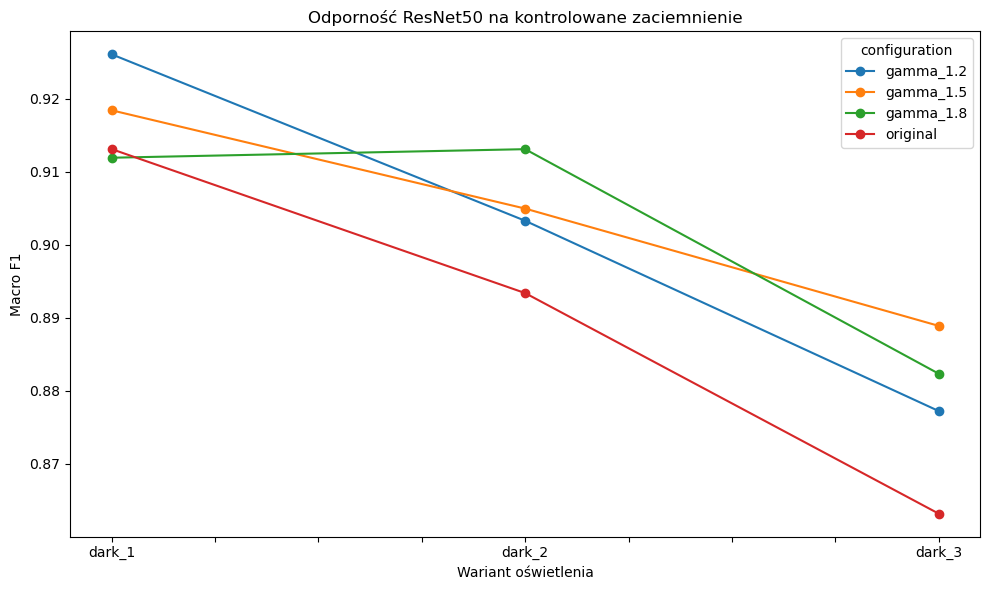

In [11]:
dark_plot = (
    dark_results_df
    .pivot(
        index="variant",
        columns="configuration",
        values="macro_f1",
    )
    .reindex(
        DARK_VARIANTS
    )
)


display(
    dark_plot
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


dark_plot.plot(
    marker="o",
    ax=ax,
)


ax.set_title(
    "Odporność ResNet50 na kontrolowane zaciemnienie"
)

ax.set_xlabel(
    "Wariant oświetlenia"
)

ax.set_ylabel(
    "Macro F1"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_dark_robustness_gamma_comparison.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 10. Wybór najlepszej konfiguracji

Konfiguracja jest wybierana na podstawie najwyższej średniej wartości `Macro F1` dla trzech poziomów zaciemnienia.

Wartości `Macro F1` dla obrazu oryginalnego oraz spadek skuteczności dla `dark_3` są wykorzystywane jako kryteria uzupełniające.

In [12]:
best_configuration = (
    dark_summary.index[0]
)


print(
    "Najlepsza konfiguracja:",
    best_configuration
)


display(
    dark_summary.loc[
        [best_configuration]
    ]
)

Najlepsza konfiguracja: gamma_1.5


,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,standard_macro_f1,f1_drop_standard_to_dark3
configuration,,,,,
gamma_1.5,0.904118,0.91879,0.88892,0.923304,0.034384


In [13]:
selection = {
    "selected_configuration":
        best_configuration,

    "selection_metric":
        "mean_dark_macro_f1",

    "results":
        dark_summary.reset_index()
        .to_dict(
            orient="records"
        ),
}


(
    METRICS_DIR
    / "selected_trained_preprocessing.json"
).write_text(
    json.dumps(
        selection,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        selection,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "selected_configuration": "gamma_1.5",
  "selection_metric": "mean_dark_macro_f1",
  "results": [
    {
      "configuration": "gamma_1.5",
      "mean_dark_macro_f1": 0.9041175457334707,
      "mean_dark_accuracy": 0.9187898089171975,
      "dark3_macro_f1": 0.8889203545024266,
      "standard_macro_f1": 0.9233044348880135,
      "f1_drop_standard_to_dark3": 0.034384080385586935
    },
    {
      "configuration": "gamma_1.8",
      "mean_dark_macro_f1": 0.9024806617321236,
      "mean_dark_accuracy": 0.9146762208067941,
      "dark3_macro_f1": 0.8823703444012061,
      "standard_macro_f1": 0.9101438781927508,
      "f1_drop_standard_to_dark3": 0.02777353379154468
    },
    {
      "configuration": "gamma_1.2",
      "mean_dark_macro_f1": 0.9022294959382933,
      "mean_dark_accuracy": 0.916135881104034,
      "dark3_macro_f1": 0.8772559202209517,
      "standard_macro_f1": 0.93118621583435,
      "f1_drop_standard_to_dark3": 0.05393029561339835
    },
    {
      "configuration"

## 11. Kontrola skuteczności dla zwiększonej jasności

Wyniki dla zwiększonej jasności służą jako dodatkowa analiza wpływu wybranego preprocessingu na warunki inne niż główny obszar badania, którym jest zaciemnienie.

In [14]:
bright_results = []


for name in [
    best_configuration
]:

    experiment = experiments[
        name
    ]

    configuration = (
        experiment[
            "configuration"
        ]
    )

    model = experiment[
        "model"
    ]


    for variant in BRIGHT_VARIANTS:

        result = evaluate_on_lighting_variant(
            model=model,
            preprocessing_method=(
                configuration[
                    "method"
                ]
            ),
            gamma=(
                configuration[
                    "gamma"
                ]
            ),
            variant=variant,
        )


        bright_results.append(
            {
                "configuration":
                    name,

                "variant":
                    variant,

                "factor":
                    LIGHTING_FACTORS[
                        variant
                    ],

                **result,
            }
        )


bright_results_df = pd.DataFrame(
    bright_results
)


display(
    bright_results_df
)


bright_results_df.to_csv(
    METRICS_DIR
    / "selected_configuration_bright_validation.csv",
    index=False,
    encoding="utf-8-sig",
)

,configuration,variant,factor,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds,samples
0,gamma_1.5,bright_1,1.3,0.936306,0.922135,0.916805,0.915714,197.701485,2512
1,gamma_1.5,bright_2,1.6,0.918790,0.898649,0.898845,0.891748,198.089292,2512
2,gamma_1.5,bright_3,2.0,0.896099,0.868248,0.879437,0.861671,195.304272,2512


## 12. Końcowa ocena wybranej konfiguracji na `test_final`


In [15]:
selected_experiment = (
    experiments[
        best_configuration
    ]
)


selected_configuration = (
    selected_experiment[
        "configuration"
    ]
)


selected_model = (
    selected_experiment[
        "model"
    ]
)


selected_test_transform = (
    build_preprocessing_eval_transform(
        selected_configuration[
            "method"
        ],
        image_size=IMAGE_SIZE,
        gamma=(
            1.5
            if selected_configuration[
                "gamma"
            ] is None
            else selected_configuration[
                "gamma"
            ]
        ),
    )
)


test_dataset = TrafficSignDataset(
    TEST_PATH,
    class_to_idx,
    transform=selected_test_transform,
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)


test_true, test_pred, test_time = (
    predict(
        selected_model,
        test_loader,
        DEVICE,
    )
)


test_metrics = evaluate_predictions(
    test_true,
    test_pred,
)


final_results = {
    "model":
        "ResNet50",

    "configuration":
        best_configuration,

    "preprocessing":
        selected_configuration[
            "method"
        ],

    "gamma":
        selected_configuration[
            "gamma"
        ],

    "balancing_strategy":
        "weighted_sampler",

    "accuracy":
        test_metrics[
            "accuracy"
        ],

    "macro_precision":
        test_metrics[
            "macro_precision"
        ],

    "macro_recall":
        test_metrics[
            "macro_recall"
        ],

    "macro_f1":
        test_metrics[
            "macro_f1"
        ],

    "test_samples":
        len(test_dataset),

    "inference_time_seconds":
        test_time,
}


print(
    json.dumps(
        final_results,
        indent=2,
    )
)

{
  "model": "ResNet50",
  "configuration": "gamma_1.5",
  "preprocessing": "gamma",
  "gamma": 1.5,
  "balancing_strategy": "weighted_sampler",
  "accuracy": 0.8959981386691485,
  "macro_precision": 0.8726121790065772,
  "macro_recall": 0.8786723672841031,
  "macro_f1": 0.8678607433941221,
  "test_samples": 4298,
  "inference_time_seconds": 336.6042698000092
}


## 13. Raport wyników dla poszczególnych klas

In [16]:
target_names = [
    idx_to_class[index]
    for index in range(
        len(class_codes)
    )
]


test_report = pd.DataFrame(
    __import__(
        "sklearn.metrics",
        fromlist=[
            "classification_report"
        ]
    ).classification_report(
        test_true,
        test_pred,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T


test_report.to_csv(
    METRICS_DIR
    / "trained_preprocessing_test_final_per_class.csv",
    encoding="utf-8-sig",
)


display(
    test_report
)

,precision,recall,f1-score,support
A-1,0.655738,0.800000,0.720721,50.000000
A-11,0.916667,1.000000,0.956522,11.000000
A-11a,1.000000,0.800000,0.888889,10.000000
A-12a,0.857143,0.857143,0.857143,21.000000
A-14,0.700000,0.636364,0.666667,11.000000
...,...,...,...,...
G-1a,1.000000,1.000000,1.000000,11.000000
G-3,0.833333,1.000000,0.909091,5.000000
accuracy,0.895998,0.895998,0.895998,0.895998
macro avg,0.872612,0.878672,0.867861,4298.000000


In [17]:
(
    METRICS_DIR
    / "trained_preprocessing_test_final.json"
).write_text(
    json.dumps(
        final_results,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

363

## 14. Porównanie z bazowym ResNet50

Końcowy wynik wybranej konfiguracji zostaje zestawiony z bazowym modelem ResNet50 wykorzystującym obrazy bez dodatkowego preprocessingu.

Porównanie pozwala określić, czy zastosowanie preprocessingu podczas treningu wpłynęło na końcową skuteczność oraz odporność modelu.

In [18]:
baseline_path = (
    METRICS_DIR
    / "architecture_final_test.json"
)


if baseline_path.exists():

    baseline = json.loads(
        baseline_path.read_text(
            encoding="utf-8"
        )
    )


    final_comparison = pd.DataFrame(
        [
            {
                "configuration":
                    "ResNet50 + original",

                "accuracy":
                    baseline[
                        "accuracy"
                    ],

                "macro_f1":
                    baseline[
                        "macro_f1"
                    ],
            },

            {
                "configuration":
                    (
                        "ResNet50 + "
                        + best_configuration
                    ),

                "accuracy":
                    final_results[
                        "accuracy"
                    ],

                "macro_f1":
                    final_results[
                        "macro_f1"
                    ],
            },
        ]
    )


    display(
        final_comparison
    )


    final_comparison.to_csv(
        METRICS_DIR
        / "trained_preprocessing_final_comparison.csv",
        index=False,
        encoding="utf-8-sig",
    )

else:

    print(
        "Nie znaleziono wyniku bazowego."
    )

,configuration,accuracy,macro_f1
0,ResNet50 + original,0.900186,0.882980
1,ResNet50 + gamma_1.5,0.895998,0.867861
